# Primary Results — Tree-Crop Agroforestry Model

All four primary figures. Change **T_MAX** (and other parameters) in the
**Global Parameters** cell — CSV caches are tagged by T_MAX so changing it
automatically triggers fresh simulations.

| Figure | Description | Runtime |
|--------|-------------|----------|
| 1 · Diagnostic | Single-season water balance traces | ~5 s |
| 2 · Sensitivity | Yield CDFs × 3 rainfall regimes | ~5 min |
| 3 · Rainfall 2D | α × λ surface (Under − Mono) | ~30 min |
| 4 · Trait surface | leaf_fraction × Zr (Under − Mono) | ~15 min |

Slow figures cache results to `output/`. Re-run just the figure cell to edit cosmetics.

In [51]:
# ── Bootstrap: load model definitions from tree.ipynb ────────────────────────
# Run from project root (maize-Toff/). Must have maize-Toff conda env active.
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm

os.makedirs('output', exist_ok=True)

_ROOT   = os.getcwd()
_SCRIPT = os.path.join(_ROOT, '_tmp_model_core.py')

if not os.path.exists(_SCRIPT):
    print('Converting tree.ipynb → _tmp_model_core.py ...')
    ret = os.system('jupyter nbconvert --to script tree.ipynb --output _tmp_model_core 2>/dev/null')
    if ret != 0 or not os.path.exists(_SCRIPT):
        sys.exit('ERROR: nbconvert failed. Run from project root with maize-Toff env active.')

with open(_SCRIPT) as f:
    _lines = f.readlines()

# Cutoff: stop before the N_SIMS=300 Monte Carlo block
_cutoff = len(_lines)
for _i, _line in enumerate(_lines):
    if _line.strip().startswith('N_SIMS = 300'):
        _cutoff = _i
        break

# Skip the hardcoded single-season diagnostic (cell 12 in tree.ipynb).
# Resume at _ALPHA_BASE (start of cell 14) — NOT at _make_climate, which
# would skip the _ALPHA_BASE / _LAMBDA_BASE assignments that _make_climate needs.
_diag_start = None
for _i, _line in enumerate(_lines):
    if 'Single-season diagnostic' in _line and '##' in _line:
        _diag_start = _i
        break

if _diag_start is not None:
    _resume = next(
        (_i for _i in range(_diag_start, _cutoff) if '_ALPHA_BASE' in _lines[_i]),
        _cutoff
    )
    _core_lines = _lines[:_diag_start] + _lines[_resume:_cutoff]
else:
    _core_lines = _lines[:_cutoff]

_EXEC_TMP = os.path.join(_ROOT, '_tmp_results_exec.py')
with open(_EXEC_TMP, 'w') as f:
    f.writelines(_core_lines)

exec(compile(open(_EXEC_TMP).read(), _EXEC_TMP, 'exec'), globals())
os.remove(_EXEC_TMP)

print('Model loaded. Ready.')

CETRAD expected annual RF: 555 mm/yr  (376 mm / 247-day season)
Model loaded. Ready.


In [52]:
# ── Global Parameters ─────────────────────────────────────────────────────────
# Edit here. CSV caches are tagged by T_MAX — changing it triggers a fresh run.

T_MAX     = 2.5   # tree transpiration ceiling [mm/day per canopy area]
CC        = 0.2   # canopy cover fraction
ALPHA_LAT = 0.5   # lateral root intensity (outside zone)
ZR        = 1500  # tree root depth [mm]

N_SIMS_MC    = 300   # seasons per regime (sensitivity / CDF figures)
N_SIMS_SWEEP = 300   # seasons per grid cell (2D sweeps)

# Primary archetype: evergreen deep, co-season leafed
TREE_PARAMS = dict(
    Zr=ZR, T_MAX=T_MAX, sw_MPa=-4.0, s_star_MPa=-0.1,
    kc=1.0, canopy_cover=CC, leaf_fraction=1.0,
)

# Rainfall regimes (CLAUDE.md §2e)
REGIMES = [
    dict(label='Few intense\n(1.5× depth, 0.67× freq)',  alpha_scale=1.5,  lambda_scale=0.67),
    dict(label='Baseline',                                alpha_scale=1.0,  lambda_scale=1.0),
    dict(label='Many small\n(0.67× depth, 1.5× freq)',   alpha_scale=0.67, lambda_scale=1.5),
]

# Cache paths tagged by T_MAX — changing T_MAX triggers fresh simulations
_TAG           = f'T{T_MAX:.1f}'
RF_SENS_CSV    = f'output/results_rf_sensitivity_{_TAG}.csv'
RAINFALL2D_CSV = f'output/results_2d_{_TAG}.csv'
TRAIT_CSV      = f'output/results_trait_{_TAG}.csv'

C_UNDER   = '#2E86AB'
C_OUTSIDE = '#E07B39'
C_MONO    = '0.4'

print(f'T_MAX={T_MAX}, CC={CC}, alpha_lat={ALPHA_LAT}, Zr={ZR}')
print(f'Cache tag: {_TAG}')


T_MAX=2.5, CC=0.2, alpha_lat=0.5, Zr=1500
Cache tag: T2.5


---
## Fig 1 — Single-season diagnostic

One deterministic season (seed=42, baseline CETRAD climate). Shows soil moisture,
crop transpiration, and tree water-use partitioning for the primary archetype.

Laikipia station data was inputted.


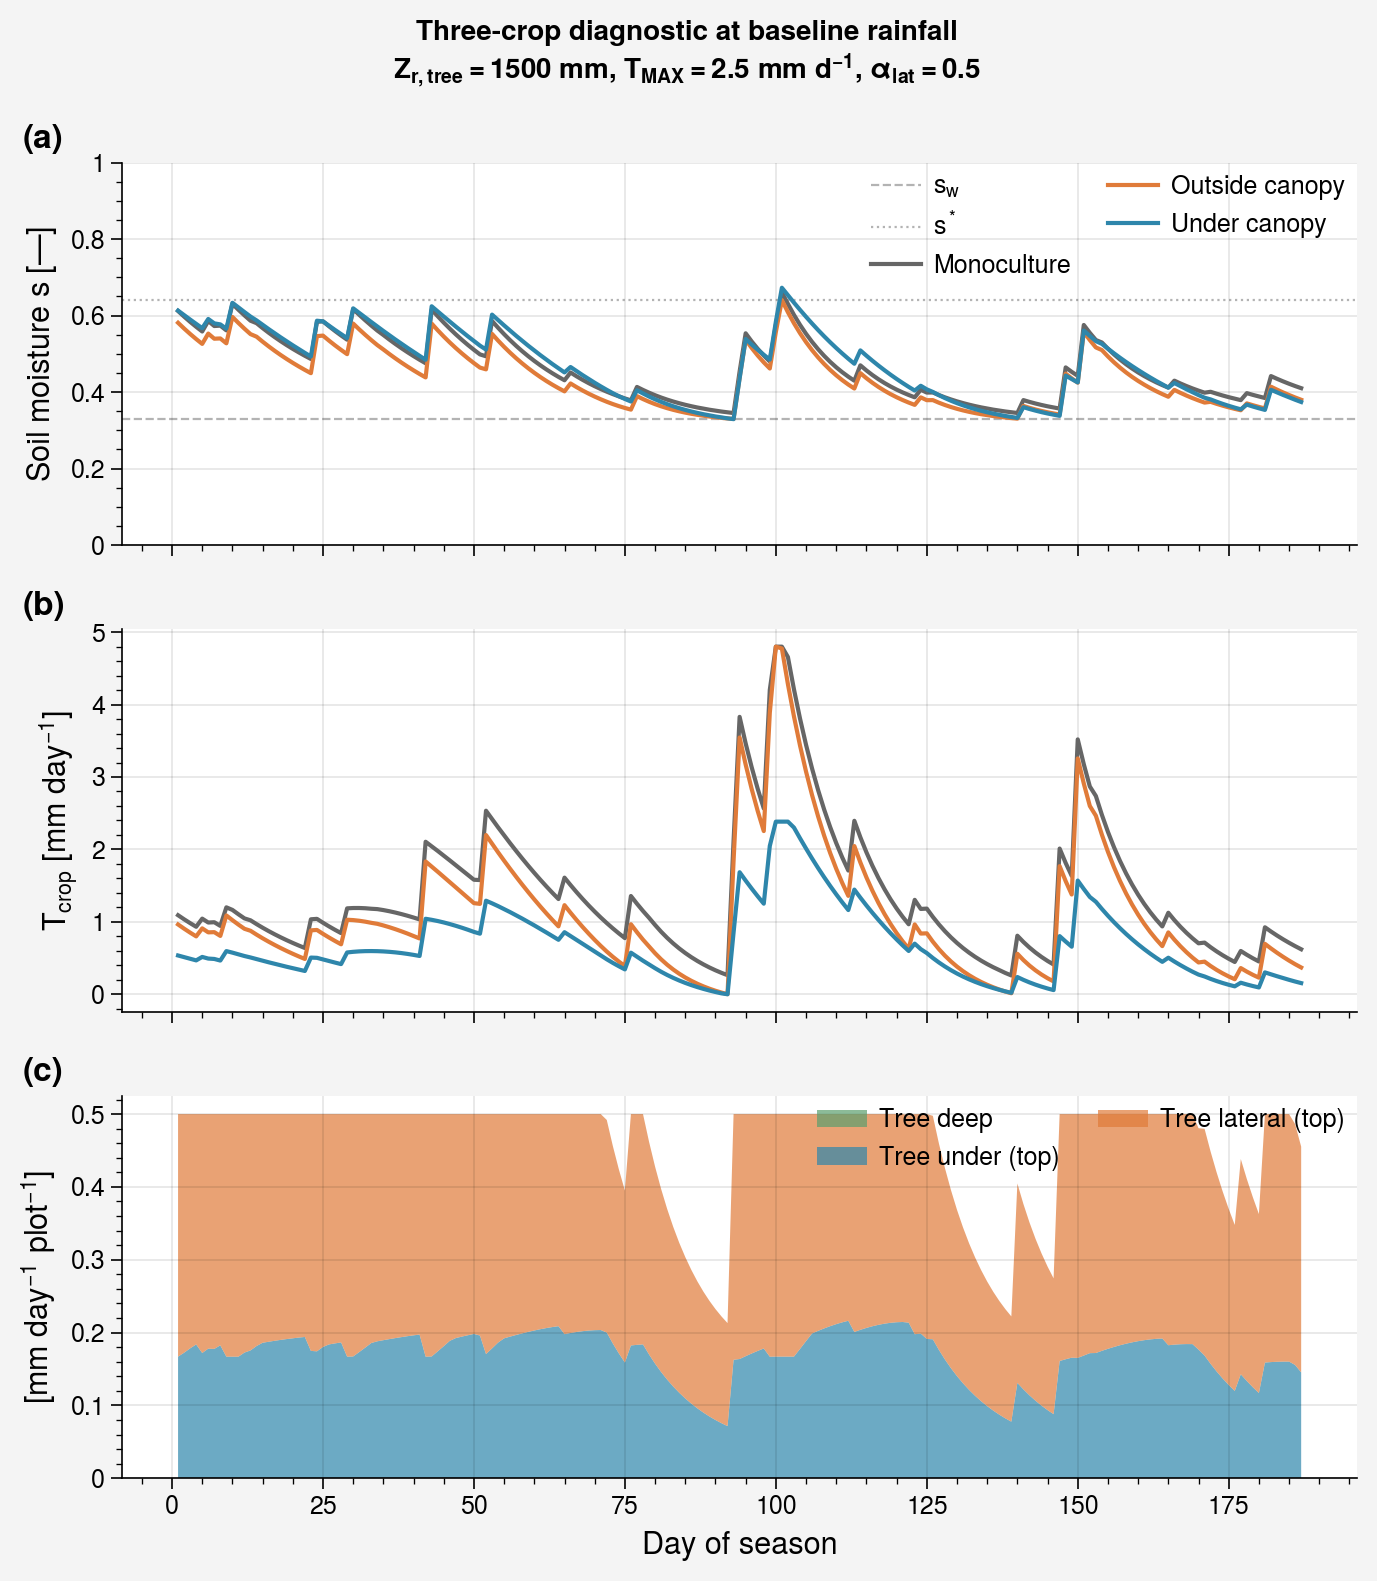

Seasonal rainfall: 512 mm
  monoculture         RF=512 mm   yield=1433 kg/acre
  under-canopy        RF=512 mm   yield=1439 kg/acre
  outside             RF=512 mm   yield=191 kg/acre


In [53]:
np.random.seed(42)
_climate_diag = Climate(**CLIMATE_KWARGS)

_crop_3, _out_u, _out_o, _out_tree = run_one_season_three(
    Soil, Crop, _climate_diag, n_spinup=5, tree_params=TREE_PARAMS,
)
_crop_m, _out_m = run_one_season(CropModel, Soil, Crop, _climate_diag, n_spinup=0)

_s_m_col = 's_top' if 's_top' in _out_m.columns else 's'
_T_m_col = 'T_crop' if 'T_crop' in _out_m.columns else 'T'

_mask  = _out_u['dos'].values > 0
_days  = _out_u['dos'].values[_mask]

_soil_ref = Soil(texture='loam')
_sw_crop  = Crop(soil=_soil_ref).sw
_s_star_c = Crop(soil=_soil_ref).s_star

fig, axes = plt.subplots(3, 1, figsize=(7, 8), sharex=True)

# (a) Soil moisture
ax = axes[0]
ax.axhline(_sw_crop,  color='0.7', lw=0.8, ls='--', zorder=0, label='$s_w$')
ax.axhline(_s_star_c, color='0.7', lw=0.8, ls=':',  zorder=0, label='$s^*$')
ax.plot(_days, _out_m[_s_m_col].values[_mask], color=C_MONO,    lw=1.5, label='Monoculture')
ax.plot(_days, _out_o['s_top'].values[_mask],  color=C_OUTSIDE, lw=1.5, label='Outside canopy')
ax.plot(_days, _out_u['s_top'].values[_mask],  color=C_UNDER,   lw=1.5, label='Under canopy')
ax.set_ylabel('Soil moisture $s$ [—]')
ax.set_ylim(0, 1)
ax.legend(loc='upper right', ncol=2)
pub_label(ax, '(a)')
despine(ax)

# (b) Crop transpiration
ax = axes[1]
ax.plot(_days, _out_m[_T_m_col].values[_mask],  color=C_MONO,    lw=1.5, label='Monoculture')
ax.plot(_days, _out_o['T_crop'].values[_mask],   color=C_OUTSIDE, lw=1.5, label='Outside canopy')
ax.plot(_days, _out_u['T_crop'].values[_mask],   color=C_UNDER,   lw=1.5, label='Under canopy')
ax.set_ylabel('$T_{crop}$ [mm day$^{-1}$]')
pub_label(ax, '(b)')
despine(ax)

# (c) Tree water-use partitioning
ax = axes[2]
ax.stackplot(
    _days,
    _out_tree['T_tree_deep'].values[_mask],
    _out_tree['T_tree_under'].values[_mask],
    _out_tree['T_tree_lateral'].values[_mask],
    labels=['Tree deep', 'Tree under (top)', 'Tree lateral (top)'],
    colors=['#5B9E6D', C_UNDER, C_OUTSIDE],
    alpha=0.7,
)
ax.set_ylabel('[mm day$^{-1}$ plot$^{-1}$]')
ax.set_xlabel('Day of season')
ax.legend(loc='upper right', ncol=2)
pub_label(ax, '(c)')
despine(ax)

fig.suptitle(
    f'Three-crop diagnostic at baseline rainfall\n'
    f'$Z_{{r,tree}}={ZR}$ mm, $T_{{MAX}}={T_MAX}$ mm d$^{{-1}}$, $\\alpha_{{lat}}={ALPHA_LAT}$',
    fontsize=10,
)
fig.tight_layout()
fig.savefig('output/threecrop_diagnostic.png')
plt.show()

# Yield summary
print(f'Seasonal rainfall: {_out_m["R"].sum():.0f} mm')
for label, crop_obj, out in [
    ('monoculture',  _crop_m, _out_m),
    ('under-canopy', _crop_3, _out_u),
    ('outside',      _crop_3, _out_o),
]:
    _, _, y, rf = season_metrics(crop_obj, out, 180)
    print(f'  {label:18s}  RF={rf:.0f} mm   yield={y:.0f} kg/acre')

---
## Fig 2 — Rainfall sensitivity

Median yield and ΔY (agroforestry effect) vs. mean seasonal rainfall.
Sweeps storm frequency (λ) at fixed CETRAD storm depth (α=1.0×).
Under−Mono and Outside−Mono with IQR bands show where and how much the tree helps or hurts.


In [54]:
# ── Simulation (cached) ───────────────────────────────────────────────────────
# Sweep lambda_scale at alpha_scale=1.0 to vary total MAP while keeping
# CETRAD storm-depth distribution fixed.
RF_LAMBDA_SCALES = [0.3, 0.4, 0.5, 0.67, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]

if os.path.exists(RF_SENS_CSV):
    print(f'Loading cached results: {RF_SENS_CSV}')
    df_rfs = pd.read_csv(RF_SENS_CSV)
else:
    print(f'Running {len(RF_LAMBDA_SCALES)} lambda scales × {N_SIMS_MC} sims each ...')
    rows = []
    for l_scale in RF_LAMBDA_SCALES:
        factory = lambda l=l_scale: _make_climate(alpha_scale=1.0, lambda_scale=l)
        df_u, df_o, df_m = simulate_three_crops_regime(
            N_SIMS_MC, climate_factory=factory, seed=42, n_spinup=5,
            tree_params=TREE_PARAMS, alpha_lateral=ALPHA_LAT,
        )
        dY_u = df_u.Yield.values - df_m.Yield.values
        dY_o = df_o.Yield.values - df_m.Yield.values
        rows.append(dict(
            lambda_scale   = l_scale,
            mean_rf        = df_m.RF.mean(),
            med_under      = df_u.Yield.median(),
            med_outside    = df_o.Yield.median(),
            med_mono       = df_m.Yield.median(),
            dY_under_med   = float(np.median(dY_u)),
            dY_under_q25   = float(np.percentile(dY_u, 25)),
            dY_under_q75   = float(np.percentile(dY_u, 75)),
            dY_outside_med = float(np.median(dY_o)),
            dY_outside_q25 = float(np.percentile(dY_o, 25)),
            dY_outside_q75 = float(np.percentile(dY_o, 75)),
        ))
        print(f'  λ={l_scale:.2f}×  RF={rows[-1]["mean_rf"]:.0f} mm  '
              f'under={rows[-1]["med_under"]:.0f}  '
              f'outside={rows[-1]["med_outside"]:.0f}  '
              f'mono={rows[-1]["med_mono"]:.0f}  '
              f'ΔY_net={rows[-1]["dY_under_med"]:+.0f}', flush=True)
    df_rfs = pd.DataFrame(rows)
    df_rfs.to_csv(RF_SENS_CSV, index=False)
    print(f'Saved → {RF_SENS_CSV}')


Loading cached results: output/results_rf_sensitivity_T2.5.csv


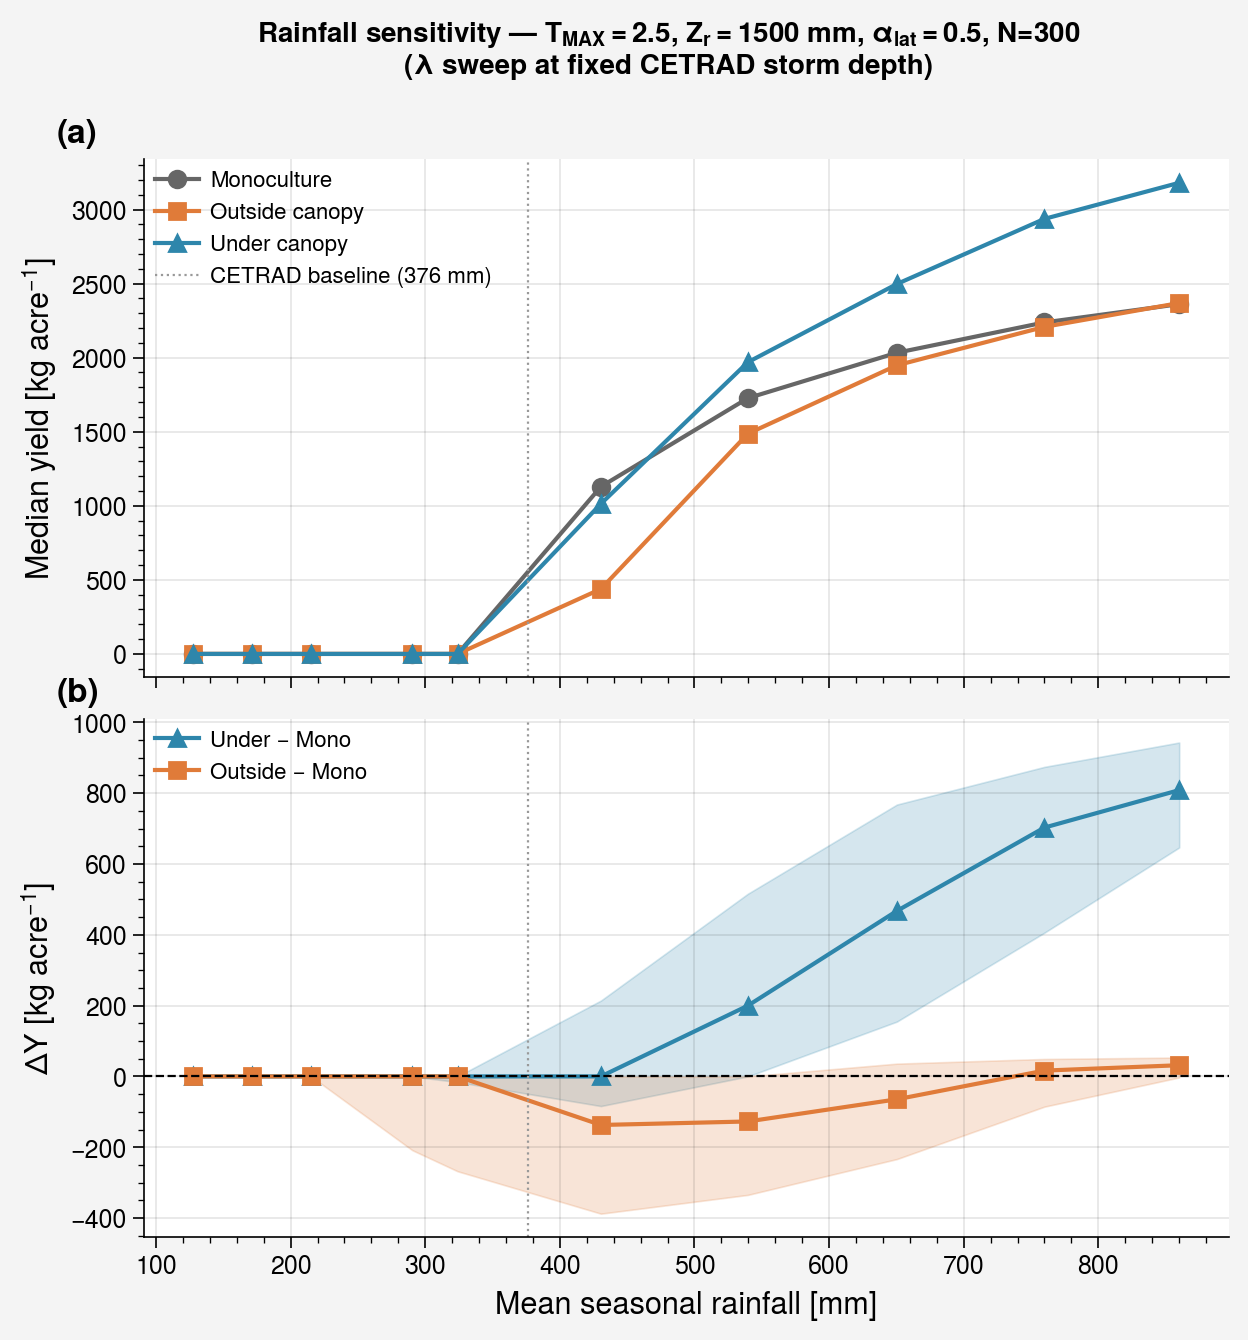

In [55]:
# ── Figure ────────────────────────────────────────────────────────────────────
rf = df_rfs['mean_rf'].values

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
fig.subplots_adjust(hspace=0.08)

# (a) Median yield vs. rainfall
ax1.plot(rf, df_rfs['med_mono'].values,    'o-', color=C_MONO,    lw=1.5, label='Monoculture')
ax1.plot(rf, df_rfs['med_outside'].values, 's-', color=C_OUTSIDE, lw=1.5, label='Outside canopy')
ax1.plot(rf, df_rfs['med_under'].values,   '^-', color=C_UNDER,   lw=1.5, label='Under canopy')
ax1.axvline(376, color='0.6', lw=0.8, ls=':', label='CETRAD baseline (376 mm)')
ax1.set_ylabel('Median yield [kg acre$^{-1}$]')
ax1.legend(fontsize=8, frameon=False)
pub_label(ax1, '(a)')
despine(ax1)

# (b) ΔY vs. rainfall with IQR band
ax2.fill_between(rf, df_rfs['dY_under_q25'].values, df_rfs['dY_under_q75'].values,
                 alpha=0.20, color=C_UNDER)
ax2.fill_between(rf, df_rfs['dY_outside_q25'].values, df_rfs['dY_outside_q75'].values,
                 alpha=0.20, color=C_OUTSIDE)
ax2.plot(rf, df_rfs['dY_under_med'].values,   '^-', color=C_UNDER,   lw=1.5, label='Under − Mono')
ax2.plot(rf, df_rfs['dY_outside_med'].values, 's-', color=C_OUTSIDE, lw=1.5, label='Outside − Mono')
ax2.axhline(0, color='k', lw=0.8, ls='--')
ax2.axvline(376, color='0.6', lw=0.8, ls=':')
ax2.set_ylabel('ΔY [kg acre$^{-1}$]')
ax2.set_xlabel('Mean seasonal rainfall [mm]')
ax2.legend(fontsize=8, frameon=False)
pub_label(ax2, '(b)')
despine(ax2)

fig.suptitle(
    f'Rainfall sensitivity — $T_{{MAX}}={T_MAX}$, $Z_r={ZR}$ mm, '
    f'$\\alpha_{{lat}}={ALPHA_LAT}$, N={N_SIMS_MC}\n'
    f'(λ sweep at fixed CETRAD storm depth)',
    fontsize=10,
)
fig.savefig('output/rainfall_sensitivity.png')
plt.show()


---
## Fig 3 — Rainfall 2D sweep (α × λ)

Under−Mono across storm depth (α) × frequency (λ) space.
Baseline CETRAD = (1.0×, 1.0×).

In [56]:
# ── Simulation (cached) ───────────────────────────────────────────────────────
ALPHA_SCALES  = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
LAMBDA_SCALES = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]

if os.path.exists(RAINFALL2D_CSV):
    print(f'Loading cached results: {RAINFALL2D_CSV}')
    df_2d = pd.read_csv(RAINFALL2D_CSV)
else:
    n_cells = len(ALPHA_SCALES) * len(LAMBDA_SCALES)
    print(f'Running {n_cells} grid cells × {N_SIMS_SWEEP} sims each ...')
    rows = []
    for a_scale in ALPHA_SCALES:
        for l_scale in LAMBDA_SCALES:
            factory = lambda a=a_scale, l=l_scale: _make_climate(alpha_scale=a, lambda_scale=l)
            df_u, df_o, df_m = simulate_three_crops_regime(
                N_SIMS_SWEEP, climate_factory=factory, seed=42,
                n_spinup=5, tree_params=TREE_PARAMS, alpha_lateral=ALPHA_LAT,
            )
            rows.append(dict(
                alpha_scale  = a_scale,
                lambda_scale = l_scale,
                mean_rf      = df_m.RF.mean(),
                mean_alpha   = np.mean(_alpha_cetrad) * a_scale,
                mean_lambda  = np.mean(_lambda_cetrad) * l_scale,
                med_under    = df_u.Yield.median(),
                med_outside  = df_o.Yield.median(),
                med_mono     = df_m.Yield.median(),
                dY_under     = df_u.Yield.median() - df_m.Yield.median(),
                dY_outside   = df_o.Yield.median() - df_m.Yield.median(),
                dY_fac       = df_u.Yield.median() - df_o.Yield.median(),
            ))
            print(f'  α={a_scale:.2f}× λ={l_scale:.2f}×  '
                  f'RF={rows[-1]["mean_rf"]:.0f} mm  '
                  f'under={rows[-1]["med_under"]:.0f}  '
                  f'outside={rows[-1]["med_outside"]:.0f}  '
                  f'mono={rows[-1]["med_mono"]:.0f}', flush=True)
    df_2d = pd.DataFrame(rows)
    df_2d.to_csv(RAINFALL2D_CSV, index=False)
    print(f'Saved → {RAINFALL2D_CSV}')

Loading cached results: output/results_2d_T2.5.csv


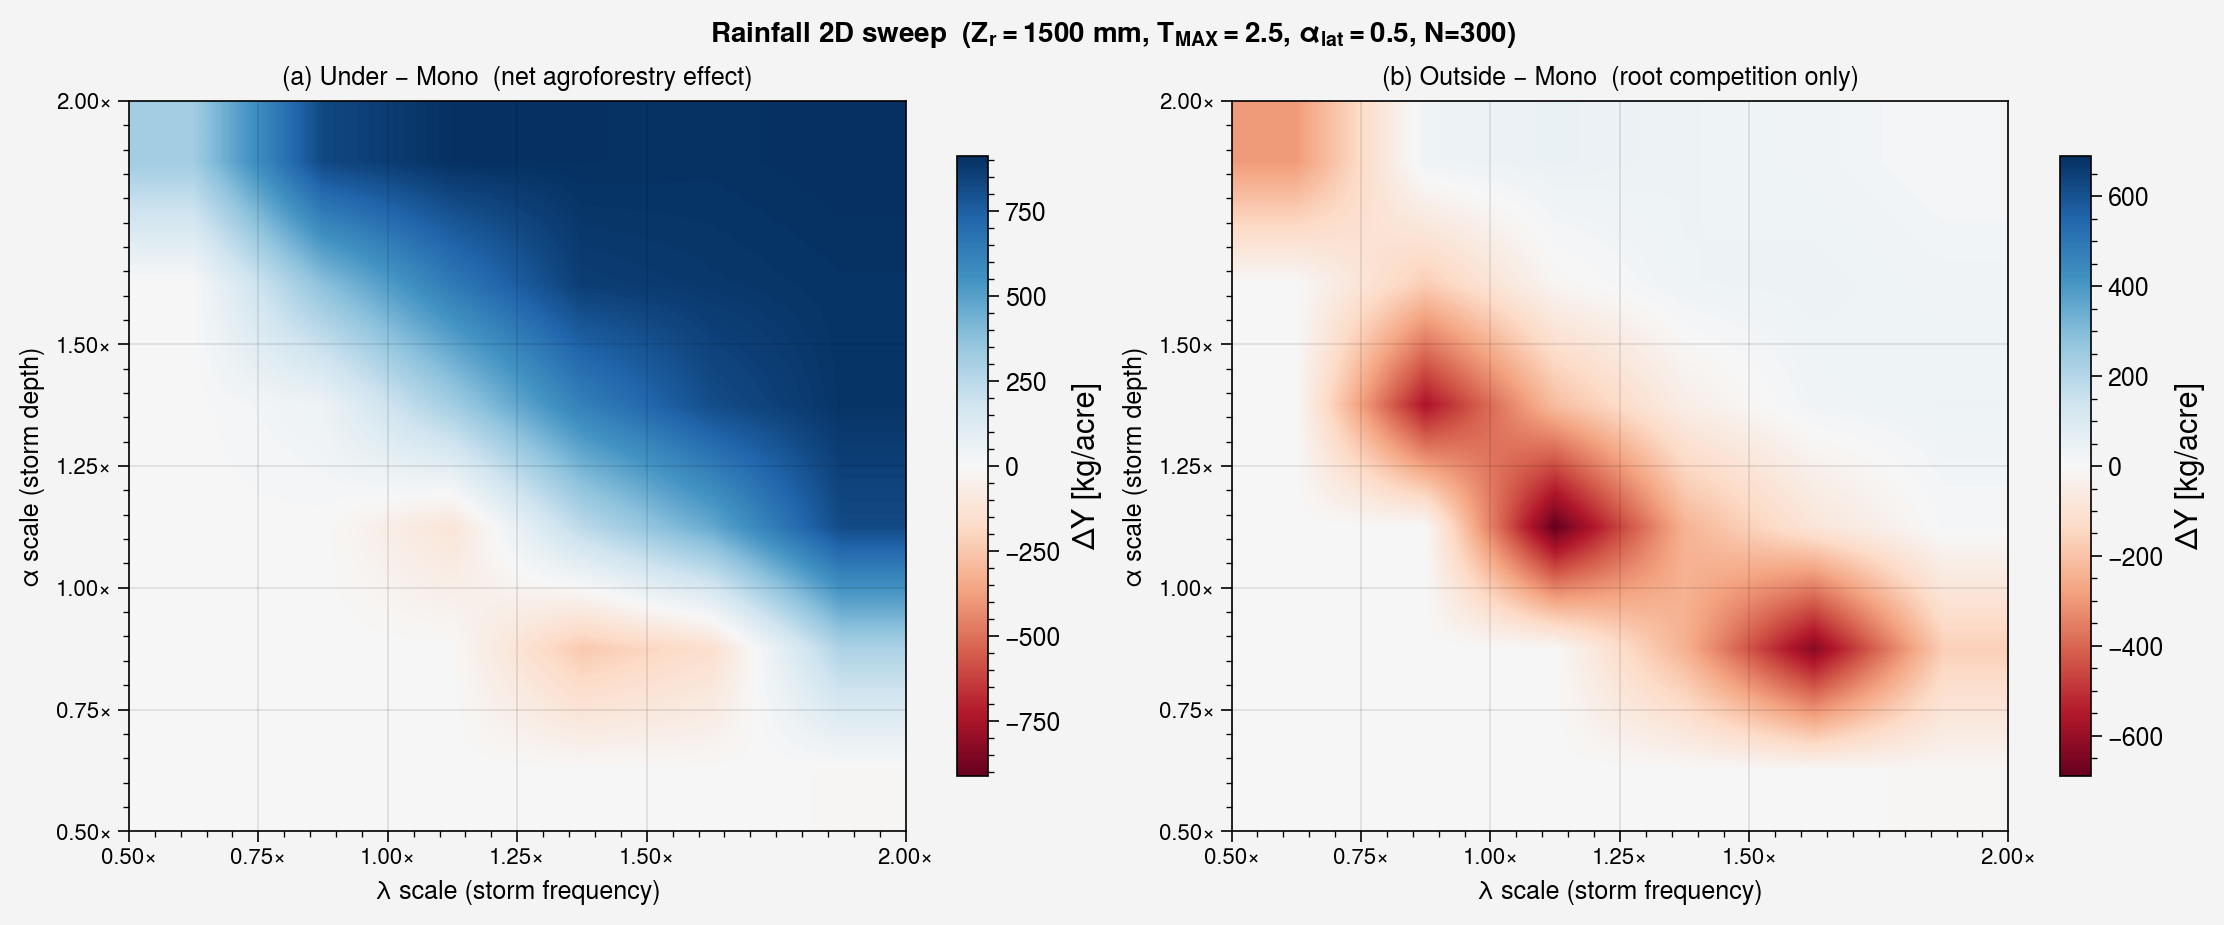

In [57]:
# ── Figure ────────────────────────────────────────────────────────────────────
a_vals = sorted(df_2d.alpha_scale.unique())
l_vals = sorted(df_2d.lambda_scale.unique())

def _pivot(col):
    return df_2d.pivot(index='alpha_scale', columns='lambda_scale', values=col)\
                .reindex(index=a_vals, columns=l_vals).values

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

panels = [
    ('dY_under',   '(a) Under − Mono  (net agroforestry effect)'),
    ('dY_outside', '(b) Outside − Mono  (root competition only)'),
]

for ax, (col, title) in zip(axes, panels):
    grid = _pivot(col)
    vmax = np.nanmax(np.abs(grid))
    if vmax == 0 or np.isnan(vmax):
        vmax = 1.0
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    im = ax.imshow(
        grid, origin='lower', aspect='auto',
        cmap='RdBu', norm=norm, interpolation='bilinear',
        extent=[l_vals[0], l_vals[-1], a_vals[0], a_vals[-1]],
    )
    ax.set_xlabel('λ scale (storm frequency)', fontsize=9)
    ax.set_ylabel('α scale (storm depth)', fontsize=9)
    ax.set_title(title, fontsize=9, pad=6)
    # Tick at each simulated grid point
    ax.set_xticks(l_vals)
    ax.set_xticklabels([f'{v:.2f}×' for v in l_vals], fontsize=8)
    ax.set_yticks(a_vals)
    ax.set_yticklabels([f'{v:.2f}×' for v in a_vals], fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.85, pad=0.03, label='ΔY [kg/acre]')

fig.suptitle(
    f'Rainfall 2D sweep  ($Z_r={ZR}$ mm, $T_{{MAX}}={T_MAX}$, '
    f'$\\alpha_{{lat}}={ALPHA_LAT}$, N={N_SIMS_SWEEP})',
    fontsize=10,
)
fig.savefig('output/rainfall_2d.png')
plt.show()


---
## Fig 4 — Trait surface (leaf_fraction × Zr)

Under−Mono and Outside−Mono across tree trait space at baseline CETRAD climate.
Stars: ★ = Faidherbia, ▲ = co-season evergreen (primary archetype).

In [58]:
# ── Simulation (cached) ───────────────────────────────────────────────────────
LF_VALS = [0.0, 0.25, 0.5, 0.75, 1.0]
ZR_VALS = [600, 800, 1000, 1250, 1500, 2000]

_factory_base = lambda: _make_climate(1.0, 1.0)

if os.path.exists(TRAIT_CSV):
    print(f'Loading cached results: {TRAIT_CSV}')
    df_trait = pd.read_csv(TRAIT_CSV)
else:
    n_cells = len(LF_VALS) * len(ZR_VALS)
    print(f'Running {n_cells} grid cells × {N_SIMS_SWEEP} sims each ...')
    rows = []
    for lf in LF_VALS:
        for zr in ZR_VALS:
            tree_p = dict(
                Zr=zr, T_MAX=T_MAX, sw_MPa=-4.0, s_star_MPa=-0.1,
                kc=1.0, canopy_cover=CC, leaf_fraction=lf,
            )
            df_u, df_o, df_m = simulate_three_crops_regime(
                N_SIMS_SWEEP, climate_factory=_factory_base, seed=42, n_spinup=5,
                tree_params=tree_p, alpha_lateral=ALPHA_LAT,
            )
            rows.append(dict(
                leaf_fraction = lf,
                Zr            = zr,
                dY_under      = (df_u.Yield - df_m.Yield).median(),
                dY_outside    = (df_o.Yield - df_m.Yield).median(),
                dY_fac        = (df_u.Yield - df_o.Yield).median(),
            ))
            print(f'  lf={lf:.2f}  Zr={zr:4d} mm  '
                  f'under={rows[-1]["dY_under"]:+.0f}  '
                  f'outside={rows[-1]["dY_outside"]:+.0f}  kg/acre', flush=True)
    df_trait = pd.DataFrame(rows)
    df_trait.to_csv(TRAIT_CSV, index=False)
    print(f'Saved → {TRAIT_CSV}')

Loading cached results: output/results_trait_T2.5.csv


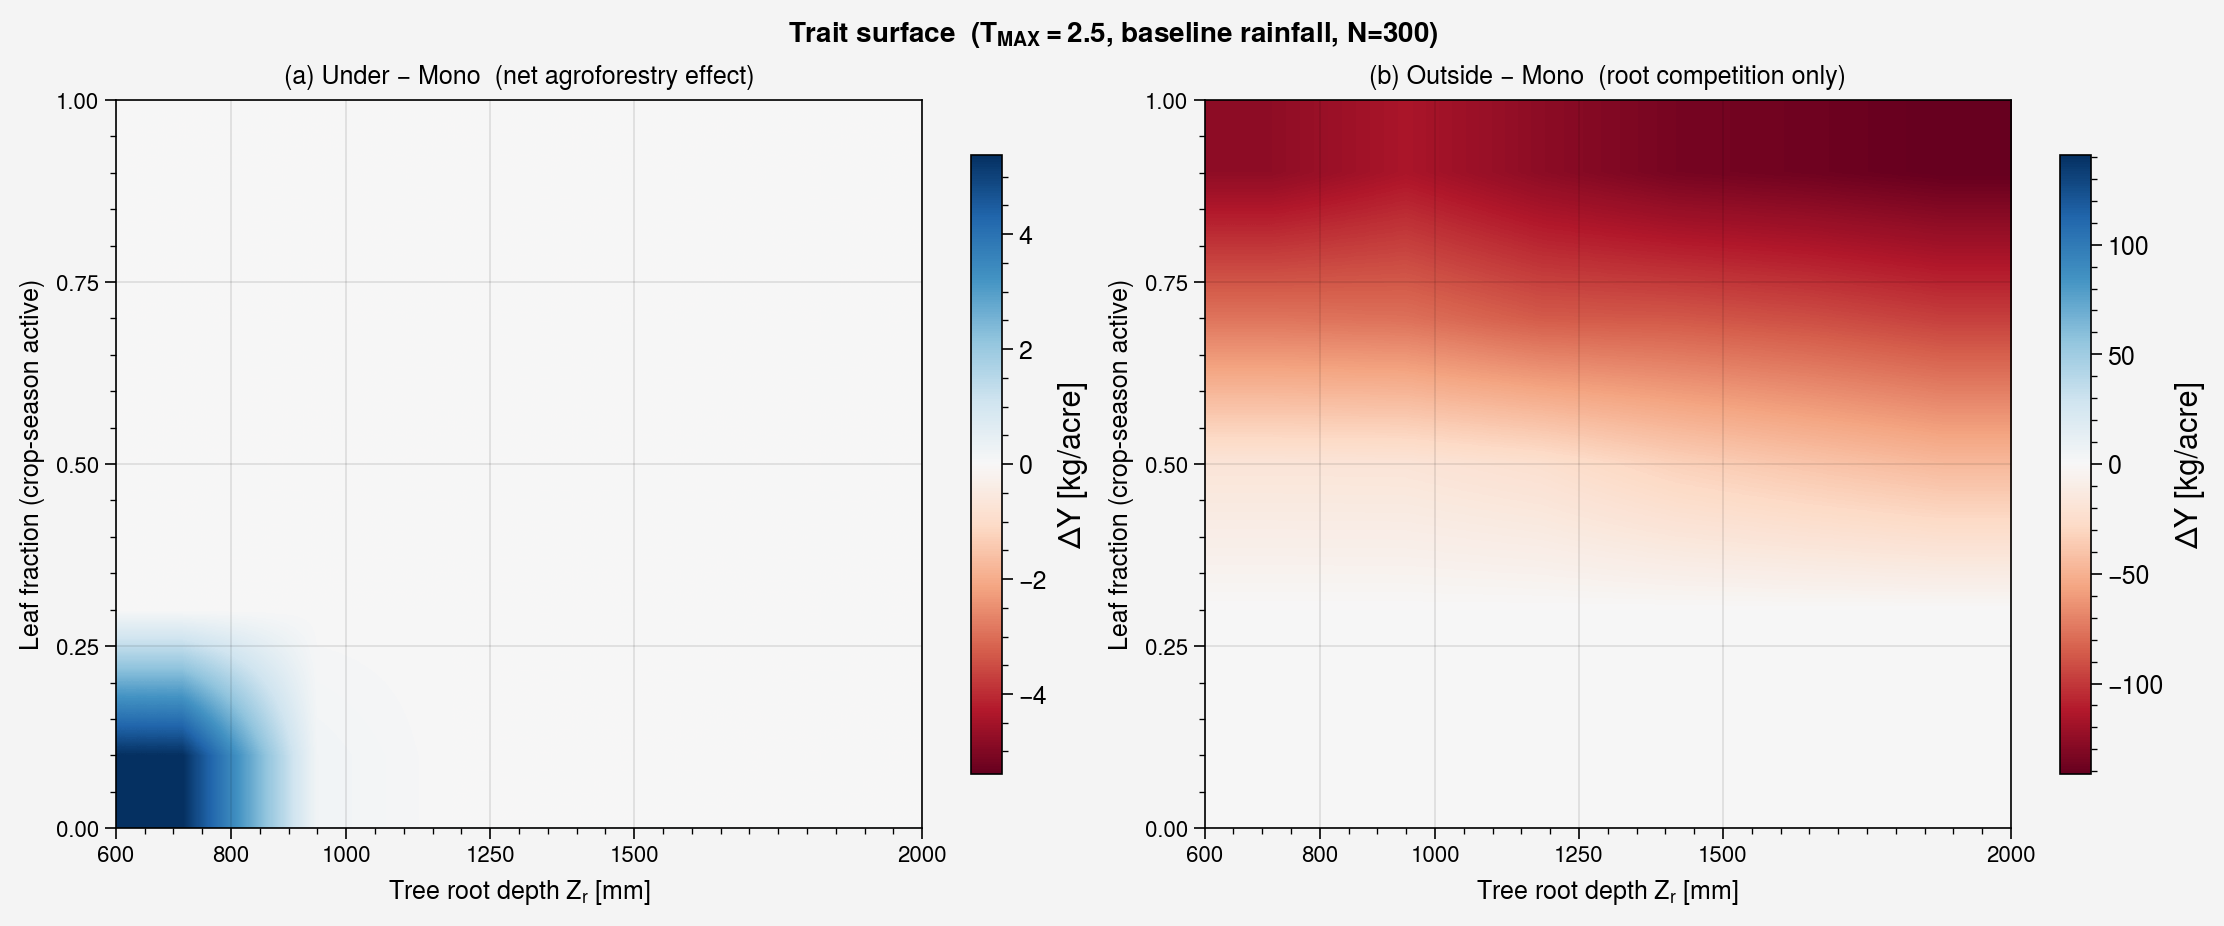

In [59]:
# ── Figure ────────────────────────────────────────────────────────────────────
lf_vals = sorted(df_trait.leaf_fraction.unique())
zr_vals = sorted(df_trait.Zr.unique())

def _trait_grid(col):
    return df_trait.pivot(index='leaf_fraction', columns='Zr', values=col)\
                   .reindex(index=lf_vals, columns=zr_vals).values

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

panels = [
    ('dY_under',   '(a) Under − Mono  (net agroforestry effect)'),
    ('dY_outside', '(b) Outside − Mono  (root competition only)'),
]

for ax, (col, title) in zip(axes, panels):
    grid = _trait_grid(col)
    vmax = np.nanmax(np.abs(grid))
    if vmax == 0 or np.isnan(vmax):
        vmax = 1.0
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    im = ax.imshow(
        grid, origin='lower', aspect='auto',
        cmap='RdBu', norm=norm, interpolation='bilinear',
        extent=[zr_vals[0], zr_vals[-1], lf_vals[0], lf_vals[-1]],
    )
    ax.set_xlabel('Tree root depth $Z_r$ [mm]', fontsize=9)
    ax.set_ylabel('Leaf fraction (crop-season active)', fontsize=9)
    ax.set_title(title, fontsize=9, pad=6)
    ax.set_xticks(zr_vals)
    ax.set_xticklabels([str(z) for z in zr_vals], fontsize=8)
    ax.set_yticks(lf_vals)
    ax.set_yticklabels([f'{lf:.2f}' for lf in lf_vals], fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.85, pad=0.03, label='ΔY [kg/acre]')

fig.suptitle(
    f'Trait surface  ($T_{{MAX}}={T_MAX}$, baseline rainfall, N={N_SIMS_SWEEP})',
    fontsize=10,
)
fig.savefig('output/trait_surface.png')
plt.show()


---
## Fig 5 — Canopy cover surface (leaf_fraction × canopy_cover)

Identical to trait surface but sweeps canopy cover instead of root depth.
Zr fixed at primary archetype value.

In [60]:
# ── Simulation (cached) ───────────────────────────────────────────────────────
LF_VALS_CC = [0.0, 0.25, 0.5, 0.75, 1.0]
CC_VALS    = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

_CC_CSV = f'output/results_cc_sweep_{_TAG}.csv'
_factory_base = lambda: _make_climate(1.0, 1.0)

if os.path.exists(_CC_CSV):
    print(f'Loading cached results: {_CC_CSV}')
    df_cc = pd.read_csv(_CC_CSV)
else:
    print(f'Running {len(LF_VALS_CC) * len(CC_VALS)} grid cells x {N_SIMS_SWEEP} sims each ...')
    rows = []
    for lf in LF_VALS_CC:
        for cc in CC_VALS:
            tree_p = dict(
                Zr=ZR, T_MAX=T_MAX, sw_MPa=-4.0, s_star_MPa=-0.1,
                kc=1.0, canopy_cover=cc, leaf_fraction=lf,
            )
            df_u, df_o, df_m = simulate_three_crops_regime(
                N_SIMS_SWEEP, climate_factory=_factory_base, seed=42, n_spinup=5,
                tree_params=tree_p, alpha_lateral=ALPHA_LAT,
            )
            rows.append(dict(
                leaf_fraction = lf,
                canopy_cover  = cc,
                dY_under      = (df_u.Yield - df_m.Yield).median(),
                dY_outside    = (df_o.Yield - df_m.Yield).median(),
            ))
            print(f'  lf={lf:.2f}  cc={cc:.2f}  '
                  f'under={rows[-1]["dY_under"]:+.0f}  '
                  f'outside={rows[-1]["dY_outside"]:+.0f}  kg/acre', flush=True)
    df_cc = pd.DataFrame(rows)
    df_cc.to_csv(_CC_CSV, index=False)
    print(f'Saved -> {_CC_CSV}')


Running 30 grid cells x 300 sims each ...
  lf=0.00  cc=0.05  under=+239  outside=+14  kg/acre
  lf=0.00  cc=0.10  under=+59  outside=+0  kg/acre
  lf=0.00  cc=0.15  under=+14  outside=+0  kg/acre
  lf=0.00  cc=0.20  under=+0  outside=+0  kg/acre
  lf=0.00  cc=0.30  under=+0  outside=+0  kg/acre
  lf=0.00  cc=0.40  under=+0  outside=+0  kg/acre
  lf=0.25  cc=0.05  under=+532  outside=+0  kg/acre
  lf=0.25  cc=0.10  under=+203  outside=+0  kg/acre
  lf=0.25  cc=0.15  under=+53  outside=+0  kg/acre
  lf=0.25  cc=0.20  under=+0  outside=+0  kg/acre
  lf=0.25  cc=0.30  under=+0  outside=-28  kg/acre
  lf=0.25  cc=0.40  under=-37  outside=-70  kg/acre
  lf=0.50  cc=0.05  under=+728  outside=+0  kg/acre
  lf=0.50  cc=0.10  under=+357  outside=+0  kg/acre
  lf=0.50  cc=0.15  under=+145  outside=+0  kg/acre
  lf=0.50  cc=0.20  under=+0  outside=-39  kg/acre
  lf=0.50  cc=0.30  under=+0  outside=-103  kg/acre
  lf=0.50  cc=0.40  under=-79  outside=-162  kg/acre
  lf=0.75  cc=0.05  under=+868  o

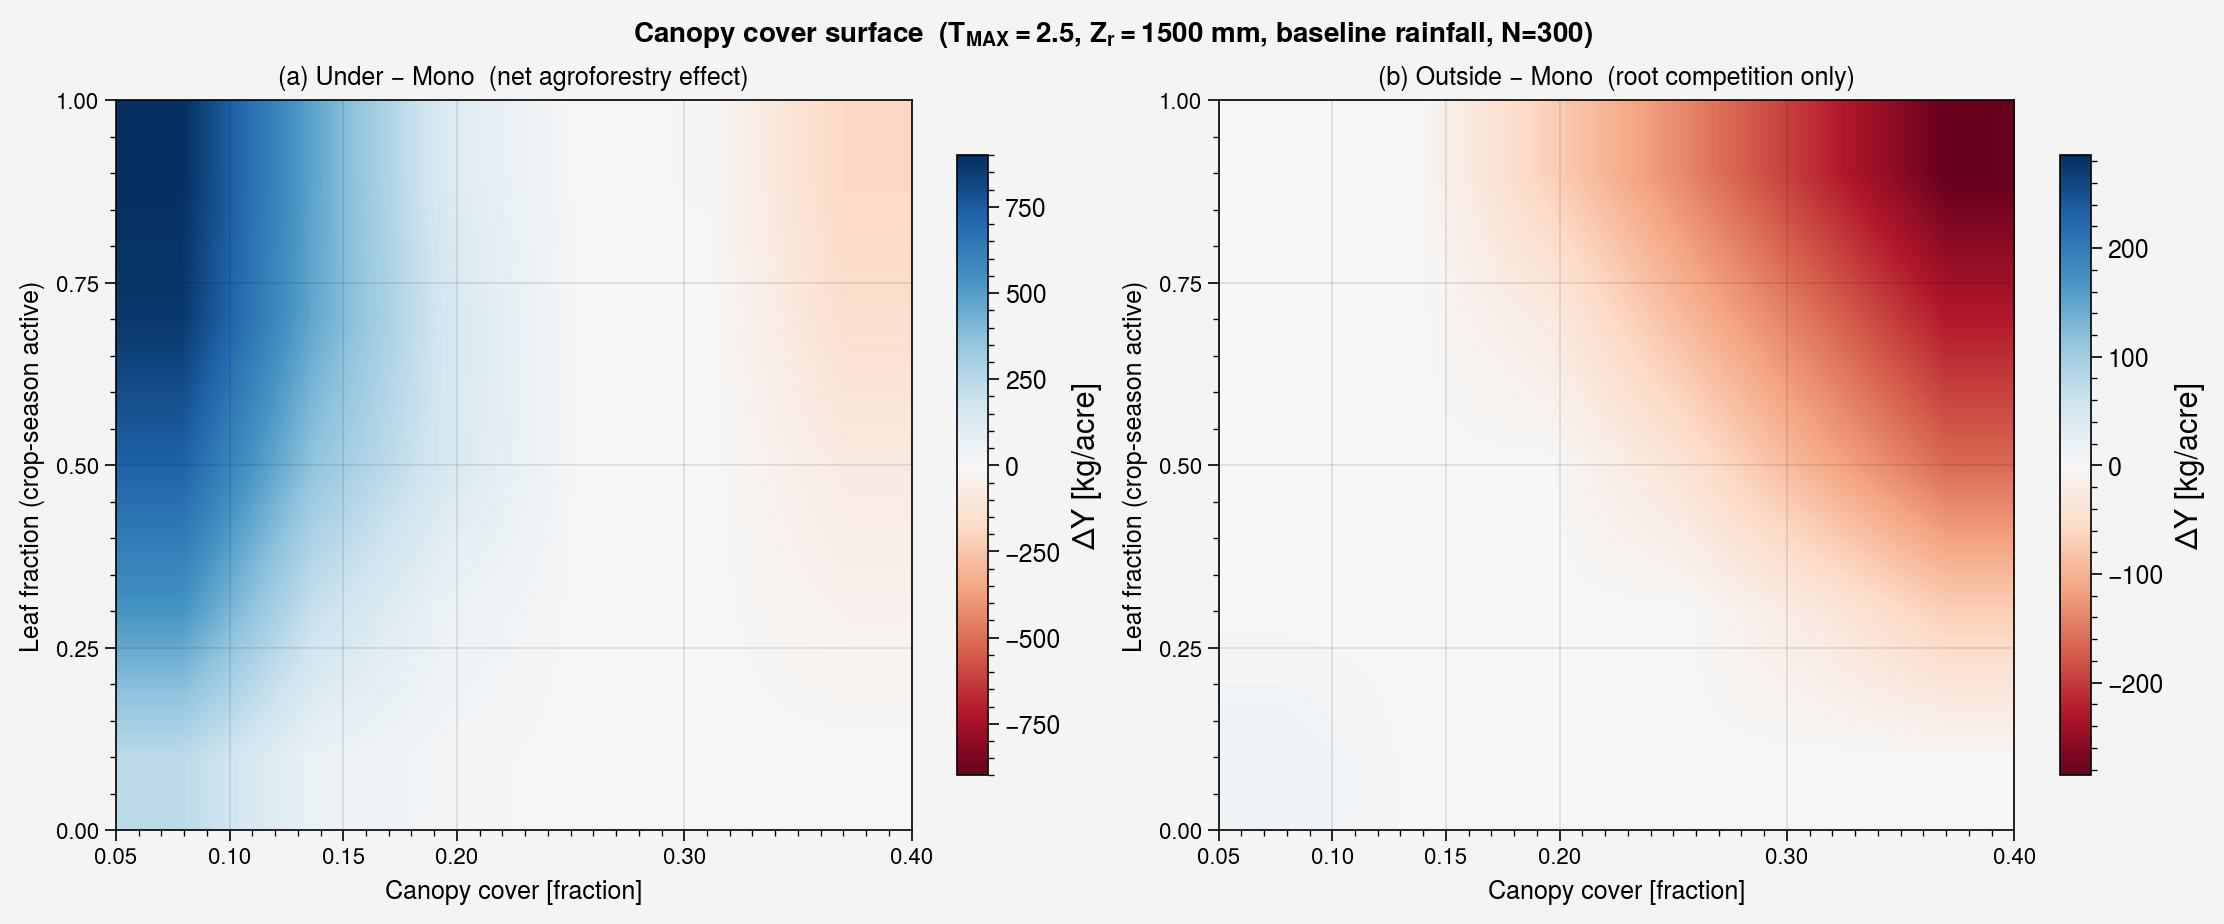

In [61]:
# ── Figure ────────────────────────────────────────────────────────────────────
lf_vals_cc = sorted(df_cc.leaf_fraction.unique())
cc_vals    = sorted(df_cc.canopy_cover.unique())

def _cc_grid(col):
    return df_cc.pivot(index='leaf_fraction', columns='canopy_cover', values=col)\
                .reindex(index=lf_vals_cc, columns=cc_vals).values

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

panels = [
    ('dY_under',   '(a) Under − Mono  (net agroforestry effect)'),
    ('dY_outside', '(b) Outside − Mono  (root competition only)'),
]

for ax, (col, title) in zip(axes, panels):
    grid = _cc_grid(col)
    vmax = np.nanmax(np.abs(grid))
    if vmax == 0 or np.isnan(vmax):
        vmax = 1.0
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    im = ax.imshow(
        grid, origin='lower', aspect='auto',
        cmap='RdBu', norm=norm, interpolation='bilinear',
        extent=[cc_vals[0], cc_vals[-1], lf_vals_cc[0], lf_vals_cc[-1]],
    )
    ax.set_xlabel('Canopy cover [fraction]', fontsize=9)
    ax.set_ylabel('Leaf fraction (crop-season active)', fontsize=9)
    ax.set_title(title, fontsize=9, pad=6)
    ax.set_xticks(cc_vals)
    ax.set_xticklabels([f'{v:.2f}' for v in cc_vals], fontsize=8)
    ax.set_yticks(lf_vals_cc)
    ax.set_yticklabels([f'{lf:.2f}' for lf in lf_vals_cc], fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.85, pad=0.03, label='ΔY [kg/acre]')

fig.suptitle(
    f'Canopy cover surface  ($T_{{MAX}}={T_MAX}$, $Z_r={ZR}$ mm, '
    f'baseline rainfall, N={N_SIMS_SWEEP})',
    fontsize=10,
)
fig.savefig('output/cc_surface.png')
plt.show()
